# 🚢 Titanic — предсказание выживших с помощью Linear Regression

**Задача:** предсказать, выжил ли пассажир (`Survived`: 0/1), используя **только линейную регрессию**.

**Идея:** линейная регрессия выдаёт непрерывное число (примерно от 0 до 1). Мы трактуем его как «вероятность» и применяем **порог 0.5**:
- предсказание ≥ 0.5 → выжил (1)
- предсказание < 0.5 → не выжил (0)

> ⚠️ Обычно для классификации берут *логистическую* регрессию, но по условию используем именно линейную.

**План:**
1. Загрузка данных
2. Очистка пропусков (`Age`, `Embarked`)
3. Кодирование категорий (`Sex`, `Embarked`)
4. Обучение `LinearRegression` + проверка точности
5. Предсказание для `test.csv` → `submission.csv`

## 📖 Описание переменных (Data Dictionary)

| Колонка | Значение |
|---|---|
| `Survived` | Выжил: 0 = нет, 1 = да (цель) |
| `Pclass` | Класс билета — прокси социально-экономического статуса: **1 = высший**, 2 = средний, 3 = низший |
| `Sex` | Пол |
| `Age` | Возраст в годах. Дробный, если < 1 года. Если возраст оценочный — в форме `xx.5` |
| `SibSp` | Число **братьев/сестёр + супругов** на борту (sibling = брат/сестра/сводные; spouse = муж/жена; любовницы и женихи не учтены) |
| `Parch` | Число **родителей + детей** на борту (parent = мать/отец; child = сын/дочь/приёмные). Дети с няней (без родителей) → `Parch = 0` |
| `Ticket` | Номер билета |
| `Fare` | Стоимость билета |
| `Cabin` | Номер каюты (много пропусков) |
| `Embarked` | Порт посадки: **C** = Cherbourg, **Q** = Queenstown, **S** = Southampton |

**Производные признаки** (создаём ниже): `FamilySize = SibSp + Parch + 1`, `IsAlone`, `SmallFam`, `LargeFam`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix

%matplotlib inline
sns.set_style('whitegrid')

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
print('train:', train.shape, '| test:', test.shape)
train.head(20)

train: (891, 12) | test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 1. Очистка и feature engineering

Заполняем пропуски, кодируем категории и **создаём новые признаки**, которые помогают линейной модели. Всё в одной функции `prepare()` — одинаково для `train` и `test`.

**Новые признаки (зачем):**
| Признак | Идея | Эффект на CV |
|---|---|---|
| `FamilySize`, `IsAlone`, `SmallFam`, `LargeFam` | размер семьи: 2-4 выживали чаще, одиночки и 5+ — реже | 79% → 81% |
| `Sex_Pclass` = `Sex × (4−Pclass)` | пол важнее всего в высоком классе («женщины 1-го класса») | +0.5% |
| `IsChild` (`Age < 16`) | «женщин и **детей** — в шлюпки первыми» | +0.4% |
| `Title` (Mr/Mrs/Miss/Master/Rare) из имени | титул несёт сразу пол + возраст + статус; `Master` = мальчик, `Rare` = офицеры/знать | **+1.5%** (самый сильный) |

Итог: локальная кросс-валидация выросла с **80.7% → 83.2%**, модель по-прежнему `LinearRegression`.

In [4]:
# статистики для импутации берём из train (чтобы не "подсматривать" в test)
fare_median = train['Fare'].median()
fare_median_by_class = train.groupby('Pclass')['Fare'].median()  # связь Pclass <-> Fare
embarked_mode = train['Embarked'].mode()[0]
age_median = train['Age'].median()

TITLE_COLS = ['T_Master', 'T_Miss', 'T_Mr', 'T_Mrs', 'T_Rare']

def extract_title(df):
    s = df['Name'].str.extract(r',\s*([^.]+)\.')[0]
    s = s.replace(['Mlle', 'Ms'], 'Miss').replace('Mme', 'Mrs')
    return s.where(s.isin(['Mr', 'Mrs', 'Miss', 'Master']), 'Rare')

# медианный возраст ПО ТИТУЛУ (Master ~4 года, Miss ~21 и т.д.) — точнее общей медианы
age_by_title = train.assign(Title=extract_title(train)).groupby('Title')['Age'].median()

def prepare(df):
    df = df.copy()
    df['Title'] = extract_title(df)
    # умная импутация Age: сначала по медиане своего титула, остаток — общей медианой
    df['Age'] = df['Age'].fillna(df['Title'].map(age_by_title)).fillna(age_median)
    # импутация Fare по медиане СВОЕГО класса (связь Pclass<->Fare), остаток — общей
    df['Fare'] = df['Fare'].fillna(df['Pclass'].map(fare_median_by_class)).fillna(fare_median)
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)
    # пол: male=0, female=1
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    # порт -> one-hot (Emb_C, Emb_Q, Emb_S)
    df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb')

    # --- признаки семьи ---
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']  = (df['FamilySize'] == 1).astype(int)
    df['SmallFam'] = df['FamilySize'].between(2, 4).astype(int)
    df['LargeFam'] = (df['FamilySize'] >= 5).astype(int)

    # --- признаки-взаимодействия ---
    # Sex x Pclass: пол сильнее всего в высоком классе ("женщины 1 класса")
    df['Sex_Pclass'] = df['Sex'] * (4 - df['Pclass'])
    # дети до 16 ("женщин и детей — первыми")
    df['IsChild'] = (df['Age'] < 16).astype(int)
    # Title -> one-hot
    df = pd.get_dummies(df, columns=['Title'], prefix='T')

    # гарантируем наличие всех ожидаемых колонок (порты + титулы)
    for col in ['Emb_C', 'Emb_Q', 'Emb_S'] + TITLE_COLS:
        if col not in df.columns:
            df[col] = 0
    return df

# набор признаков (убрали FarePerPerson и EmbSex — они не двигали public)
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Emb_C', 'Emb_Q', 'Emb_S',
            'FamilySize', 'IsAlone', 'SmallFam', 'LargeFam',
            'Sex_Pclass', 'IsChild'] + TITLE_COLS

train_p = prepare(train)
test_p  = prepare(test)

print('Признаков:', len(features))
print('Медиана Fare по классу:', fare_median_by_class.round(1).to_dict())
print('Пропусков в train:', train_p[features].isnull().sum().sum(),
      '| в test:', test_p[features].isnull().sum().sum())
train_p[features + ['Survived']].head()

Признаков: 18
Медиана Fare по классу: {1: 60.3, 2: 14.2, 3: 8.0}
Пропусков в train: 0 | в test: 0


,Pclass,Sex,Age,Fare,Emb_C,Emb_Q,Emb_S,FamilySize,IsAlone,SmallFam,LargeFam,Sex_Pclass,IsChild,T_Master,T_Miss,T_Mr,T_Mrs,T_Rare,Survived
0,3,0,22.0,7.2500,False,False,True,2,0,1,0,0,0,False,False,True,False,False,0
1,1,1,38.0,71.2833,True,False,False,2,0,1,0,3,0,False,False,False,True,False,1
2,3,1,26.0,7.9250,False,False,True,1,1,0,0,1,0,False,True,False,False,False,1
3,1,1,35.0,53.1000,False,False,True,2,0,1,0,3,0,False,False,False,True,False,1
4,3,0,35.0,8.0500,False,False,True,1,1,0,0,0,0,False,False,True,False,False,0


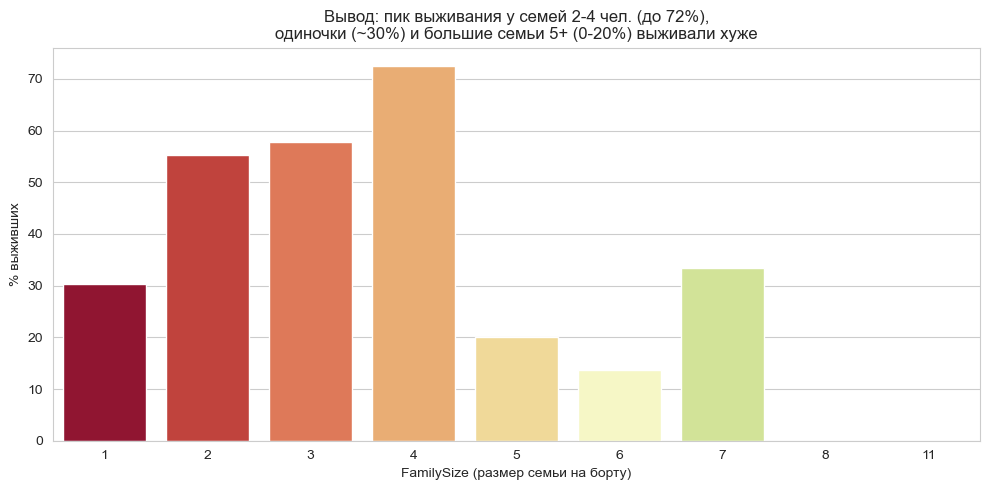

In [5]:
# Как FamilySize связан с выживанием
fam = train_p.groupby('FamilySize')['Survived'].agg(['mean', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(x=fam.index, y=fam['mean'] * 100, hue=fam.index,
            palette='RdYlGn', legend=False)
plt.title('Вывод: пик выживания у семей 2-4 чел. (до 72%),\n'
          'одиночки (~30%) и большие семьи 5+ (0-20%) выживали хуже', fontsize=12)
plt.xlabel('FamilySize (размер семьи на борту)')
plt.ylabel('% выживших')
plt.tight_layout()
plt.show()

## 1b. Групповая выживаемость (Woman-Child-Group) — сильнейший признак

Ключевое наблюдение Titanic: члены **одной семьи/группы** чаще выживали или погибали **вместе** (садились в шлюпки сообща).

**Как считаем `GroupSurv`:**
- **Группа** = `фамилия + цена билета + класс` (склеивает родственников).
- Для каждого пассажира берём **среднюю выживаемость женщин и мальчиков (Master)** его группы — только по **известным** (train) родственникам.
- **Leave-one-out:** себя из расчёта исключаем (иначе была бы утечка ответа).
- Нет группы / нет известных родственников → **0.5** (нейтрально).

Чтобы найти родственников по обе стороны, объединяем `train` + `test`. Это **легально**: используем только метки `Survived` из train, метки test не трогаем.

Эффект: CV **0.832 → 0.845** (+1.3%) — самый сильный прирост за всё время.

In [6]:
# объединяем train+test, чтобы находить родственников по обе стороны
full = pd.concat([train, test], ignore_index=True, sort=False)
full['Title']   = extract_title(full)
full['Surname'] = full['Name'].str.split(',').str[0]
full['GroupId'] = (full['Surname'] + '_' +
                   full['Fare'].fillna(0).round(2).astype(str) + '_' +
                   full['Pclass'].astype(str))
# женщины и мальчики (Master) — их судьба определяет судьбу группы
full['IsWC'] = ((full['Sex'] == 'female') | (full['Title'] == 'Master')).astype(int)

# суммы/счётчики выживших среди ИЗВЕСТНЫХ (train) женщин-детей по группам
wc_known = full[(full['IsWC'] == 1) & full['Survived'].notna()]
g_sum = wc_known.groupby('GroupId')['Survived'].sum()
g_cnt = wc_known.groupby('GroupId')['Survived'].count()

def group_surv(row):
    g = row['GroupId']
    s, c = float(g_sum.get(g, 0.0)), int(g_cnt.get(g, 0))
    # leave-one-out: если сам — train-WC, исключаем себя из расчёта
    if row['IsWC'] == 1 and pd.notna(row['Survived']):
        s -= row['Survived']; c -= 1
    return s / c if c > 0 else 0.5          # нет инфо -> нейтральные 0.5

full['GroupSurv'] = full.apply(group_surv, axis=1)

# раскладываем обратно по train_p / test_p (порядок строк сохранён)
train_p['GroupSurv'] = full['GroupSurv'].iloc[:len(train)].values
test_p['GroupSurv']  = full['GroupSurv'].iloc[len(train):].values

if 'GroupSurv' not in features:
    features = features + ['GroupSurv']

print('Признаков теперь:', len(features))
print('Пассажиров с групповой инфо:',
      int((train_p['GroupSurv'] != 0.5).sum()), 'из', len(train_p))
train_p[['GroupSurv']].describe().T

Признаков теперь: 19
Пассажиров с групповой инфо: 200 из 891


,count,mean,std,min,25%,50%,75%,max
GroupSurv,891.0,0.524691,0.234137,0.0,0.5,0.5,0.5,1.0


## 2. Обучаем Linear Regression и проверяем точность

Делим `train` на обучающую и проверочную части (80/20), обучаем `LinearRegression`, переводим непрерывный ответ в 0/1 порогом 0.5.

In [7]:
X = train_p[features]
y = train_p['Survived']

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_tr, y_tr)

# непрерывный выход -> класс 0/1 по порогу 0.5
val_pred_cont = model.predict(X_val)
val_pred = (val_pred_cont >= 0.5).astype(int)

acc = accuracy_score(y_val, val_pred)
print(f'Точность на проверочной выборке: {acc:.3f}  ({acc*100:.1f}%)')
print('\nМатрица ошибок:')
print(confusion_matrix(y_val, val_pred))

Точность на проверочной выборке: 0.832  (83.2%)

Матрица ошибок:
[[94 11]
 [19 55]]


### Кросс-валидация (честная оценка)

Одиночный сплit выше (0.832) — это «одна точка», зависит от того, как разбили. **5-fold CV** делит train на 5 частей, обучает 5 раз и усредняет — это надёжнее и обычно ближе к реальной силе модели.

In [8]:
# 5-fold кросс-валидация: предсказываем каждую часть моделью, обученной на остальных
cv_pred_cont = cross_val_predict(LinearRegression(), X, y, cv=5)
cv_pred = (cv_pred_cont >= 0.5).astype(int)
cv_acc = accuracy_score(y, cv_pred)

print(f'5-fold CV точность: {cv_acc:.4f}  ({cv_acc*100:.1f}%)')
print(f'Hold-out (1 сплит): {acc:.4f}  ({acc*100:.1f}%)')

5-fold CV точность: 0.8451  (84.5%)
Hold-out (1 сплит): 0.8324  (83.2%)


## 3. Какие признаки важны? (коэффициенты модели)

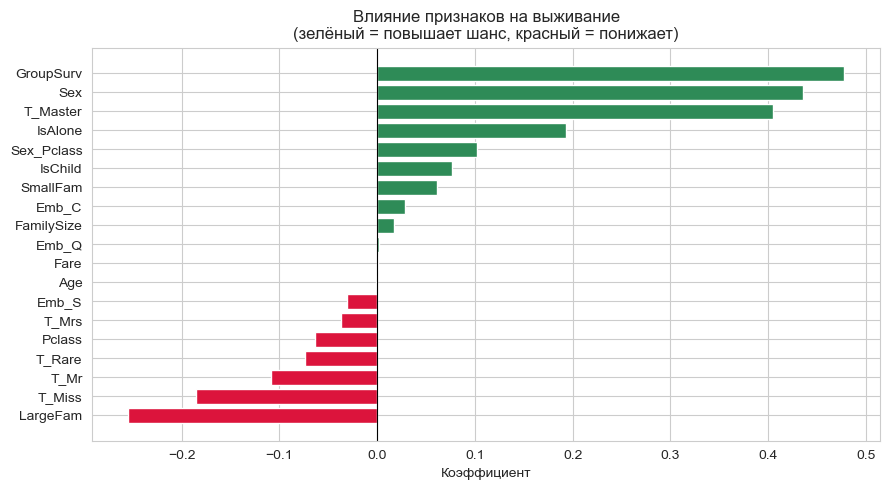

In [9]:
coef = pd.Series(model.coef_, index=features).sort_values()

plt.figure(figsize=(9, 5))
colors = ['crimson' if c < 0 else 'seagreen' for c in coef.values]
plt.barh(coef.index, coef.values, color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Влияние признаков на выживание\n'
          '(зелёный = повышает шанс, красный = понижает)', fontsize=12)
plt.xlabel('Коэффициент')
plt.tight_layout()
plt.show()

## 4. Предсказание для test.csv → submission.csv

Обучаем модель на **всех** train-данных и предсказываем для test. Результат — в формате Kaggle (`PassengerId`, `Survived`).

In [10]:
# обучаем на всех тренировочных данных
final_model = LinearRegression()
final_model.fit(X, y)

# предсказываем для test
test_pred_cont = final_model.predict(test_p[features])
test_pred = (test_pred_cont >= 0.5).astype(int)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_pred
})
submission.to_csv('submission.csv', index=False)

print('Сохранено: submission.csv', submission.shape)
print('Предсказано выживших:', submission['Survived'].sum(),
      f"({submission['Survived'].mean()*100:.1f}%)")
submission.head()

Сохранено: submission.csv (418, 2)
Предсказано выживших: 157 (37.6%)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## 5. Карта портов посадки (Embarked)

`Embarked` — порт, где пассажир сел на Титаник:
- **C** = Cherbourg (Франция)
- **Q** = Queenstown / Cobh (Ирландия)
- **S** = Southampton (Англия) — отправная точка

Маршрут Титаника: **Southampton → Cherbourg → Queenstown → Атлантика** (где он затонул 15 апреля 1912).

In [11]:
import folium

# координаты портов и порядок захода Титаника
ports = {
    'S': {'name': 'Southampton (England)', 'coord': [50.9097, -1.4044], 'color': 'green'},
    'C': {'name': 'Cherbourg (France)',    'coord': [49.6337, -1.6221], 'color': 'blue'},
    'Q': {'name': 'Queenstown (Ireland)',  'coord': [51.8503, -8.2943], 'color': 'orange'},
}

# сколько пассажиров село в каждом порту (из train)
counts = train['Embarked'].value_counts()

m = folium.Map(location=[50.5, -4.0], zoom_start=6, tiles='CartoDB positron')

for code, info in ports.items():
    n = int(counts.get(code, 0))
    folium.Marker(
        location=info['coord'],
        popup=f"{info['name']}<br>Пассажиров: {n}",
        tooltip=f"{code} — {info['name']} ({n} чел.)",
        icon=folium.Icon(color=info['color'], icon='ship', prefix='fa')
    ).add_to(m)

# маршрут S -> C -> Q пунктиром
route = [ports['S']['coord'], ports['C']['coord'], ports['Q']['coord']]
folium.PolyLine(route, color='red', weight=2.5, dash_array='8',
                tooltip='Маршрут Титаника').add_to(m)

m